# 🎗️ De la mamografía a la detección: pensando como una IA

**Taller guiado · 45–60 minutos · sin entrenamiento de modelos**

En tres casos de CBIS-DDSM, observarás la mamografía completa, formularás una hipótesis sobre la ubicación de una anomalía, consultarás los metadatos y finalmente revelarás la máscara de referencia. La actividad simula el razonamiento de localización; **no es una herramienta clínica ni un sistema de IA entrenado**.

**Regla del ejercicio:** ejecuta las celdas en orden. Detente en cada pregunta antes de revelar la siguiente etapa. Este proyecto incluye copias intactas de los DICOM de los tres casos; la carpeta fuente original permanece sin cambios.


## 0. Preparación

**En este proyecto:** abre este notebook desde la carpeta `notebooks` y ejecuta la celda siguiente.

**En Google Colab:** sube el archivo `taller_colab.zip` cuando la celda lo solicite. El ZIP contiene este notebook y los tres casos; no necesitas montar Google Drive ni descargar CBIS-DDSM completo. La primera ejecución requiere conexión solo para subir el ZIP.


In [25]:
from pathlib import Path
import json, io, zipfile, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt
try:
    import pydicom
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pydicom>=3,<4", "-q"])
    import pydicom
from functools import lru_cache

candidatos = [Path('data/taller'), Path('../data/taller'), Path('/content/data/taller')]
DATOS = next((p for p in candidatos if (p / 'casos.json').exists()), None)
if DATOS is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError('No encuentro data/taller. Abre el notebook desde el proyecto o usa taller_colab.zip en Colab.')
    print('Sube taller_colab.zip:')
    subidos = files.upload()
    nombre = next((n for n in subidos if n.endswith('.zip')), None)
    if nombre is None:
        raise ValueError('Se necesita taller_colab.zip.')
    with zipfile.ZipFile(io.BytesIO(subidos[nombre])) as z:
        if any(Path(n).is_absolute() or '..' in Path(n).parts for n in z.namelist()):
            raise ValueError('ZIP con rutas no válidas.')
        z.extractall('/content')
    DATOS = Path('/content/data/taller')

casos = json.loads((DATOS / 'casos.json').read_text(encoding='utf-8'))
@lru_cache(maxsize=6)
def leer_imagen(ruta):
    ds = pydicom.dcmread(DATOS / ruta)
    datos = ds.pixel_array.astype(np.float32)
    validos = datos[datos > 0]
    if validos.size == 0:
        raise ValueError(f'Imagen sin valores positivos: {ruta}')
    bajo, alto = np.percentile(validos, [0.5, 99.7])
    if alto <= bajo:
        raise ValueError(f'Contraste insuficiente: {ruta}')
    datos = np.clip((datos - bajo) / (alto - bajo), 0, 1)
    if ds.PhotometricInterpretation == 'MONOCHROME1':
        datos = 1 - datos
    return (datos * 255).astype(np.uint8)

@lru_cache(maxsize=3)
def leer_mascara(ruta):
    return pydicom.dcmread(DATOS / ruta).pixel_array > 0

print(f'Listo: {len(casos)} casos DICOM disponibles en {DATOS}')


Listo: 3 casos DICOM disponibles en ..\data\taller


## 1. Observar antes de leer

Comienza con el **caso 1**. Mira la imagen completa, sin máscara ni resultado. ¿Qué región revisarías con más atención? ¿Qué rasgo visual te llama la atención? Anota tu respuesta antes de seguir.


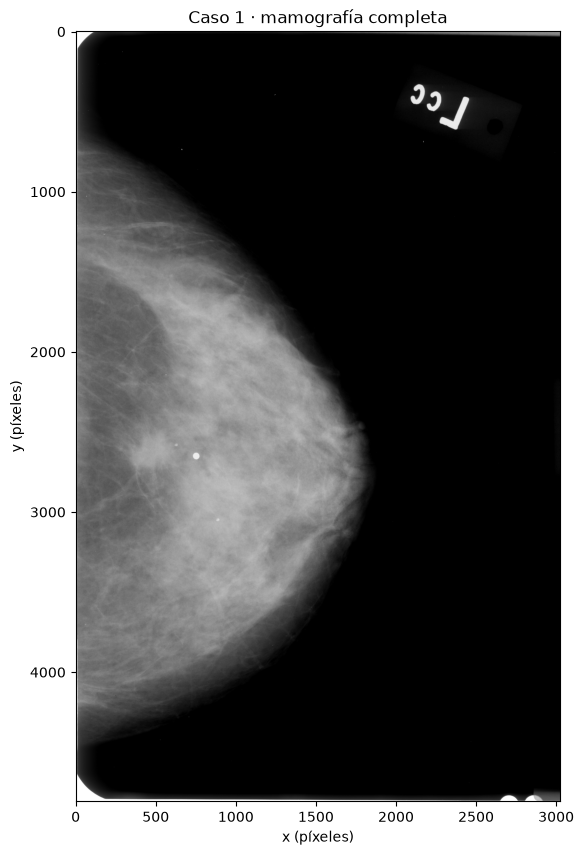

In [26]:
def mostrar_imagen(numero):
    caso = casos[numero - 1]
    imagen = leer_imagen(caso['imagen'])
    fig, ax = plt.subplots(figsize=(7, 10))
    ax.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Caso {numero} · mamografía completa')
    ax.set_xlabel('x (píxeles)')
    ax.set_ylabel('y (píxeles)')
    plt.show()

mostrar_imagen(1)


**Tu hipótesis (caso 1):** ubicación aproximada: __________ · evidencia visual: __________

La proyección **CC** observa la mama desde arriba; **MLO** usa una proyección oblicua. Una imagen aislada ofrece información limitada: en la práctica se interpretan otras vistas y datos clínicos.


## 2. Consultar metadatos sin revelar la respuesta

Los metadatos orientan la lectura. Aquí se muestran datos descriptivos del caso, pero se reserva la patología y la máscara hasta después de que hagas tu hipótesis.


In [15]:
def metadatos(numero):
    c = casos[numero - 1]
    etiquetas = {'LEFT':'izquierda', 'RIGHT':'derecha', 'mass':'masa', 'calcification':'calcificaciones'}
    print(f"Caso {numero} | mama {etiquetas.get(c['lado'], c['lado'])} | vista {c['vista']}")
    print('Tipo de hallazgo anotado:', etiquetas.get(c['tipo'], c['tipo']))
    print('Densidad registrada:', c['densidad'])
    ds = pydicom.dcmread(DATOS / c['imagen'], stop_before_pixels=True)
    print(f'DICOM: {ds.Rows} × {ds.Columns} píxeles | {ds.BitsStored} bits | {ds.PhotometricInterpretation}')
    if c['tipo'] == 'mass':
        print('Forma:', c['forma'], '| márgenes:', c['margen'])
    else:
        print('Tipo de calcificación:', c['tipo_calcificacion'], '| distribución:', c['distribucion'])

metadatos(1)


Caso 1 | mama izquierda | vista CC
Tipo de hallazgo anotado: masa
Densidad registrada: 3
DICOM: 4808 × 3024 píxeles | 16 bits | MONOCHROME2
Forma: IRREGULAR-ARCHITECTURAL_DISTORTION | márgenes: SPICULATED


**Tras leer los metadatos:** ¿mantienes tu ubicación inicial? ¿Qué campo te ayudó y cuál podría sesgarte? __________

La densidad, la forma y los márgenes son descripciones del registro. No deben interpretarse como una confirmación de patología por sí solos.


## 3. Señalar una región y revelar la máscara

Escribe en `x` e `y` el punto aproximado que elegiste, usando las coordenadas en píxeles que aparecen en los ejes de la imagen. Puedes ejecutar de nuevo la celda con otros valores. El punto es una **simulación de la elección humana**, no una predicción automática.


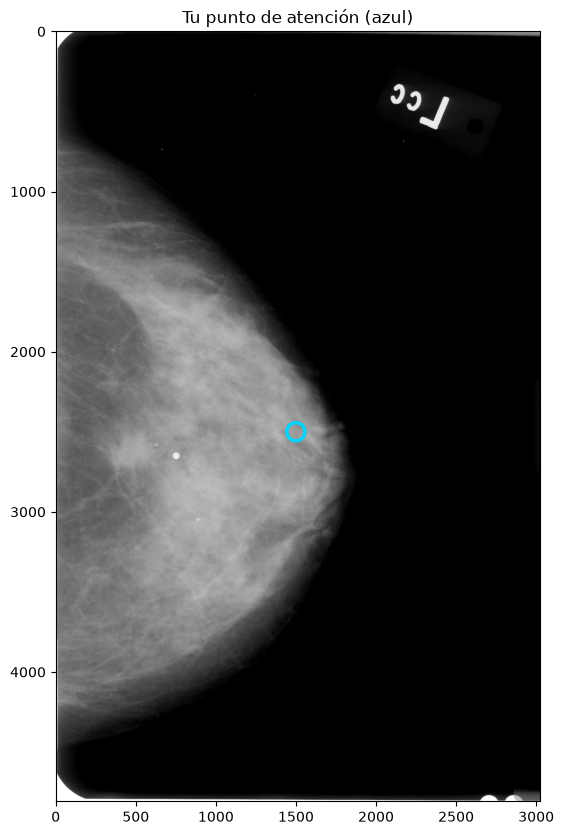

In [16]:
numero = 1
x, y = 1500, 2500  # Cambia estas coordenadas antes de revelar la referencia.
c = casos[numero - 1]
imagen = leer_imagen(c['imagen'])
fig, ax = plt.subplots(figsize=(7, 10))
ax.imshow(imagen, cmap='gray', vmin=0, vmax=255)
ax.scatter([x], [y], s=170, facecolors='none', edgecolors='#00d4ff', linewidths=2.5)
ax.set_xlim(0, imagen.shape[1]); ax.set_ylim(imagen.shape[0], 0)
ax.set_title('Tu punto de atención (azul)')
plt.show()


**Pausa:** compara mentalmente tu marca con tu primera observación. Ejecuta la siguiente celda solo cuando hayas registrado tu hipótesis.


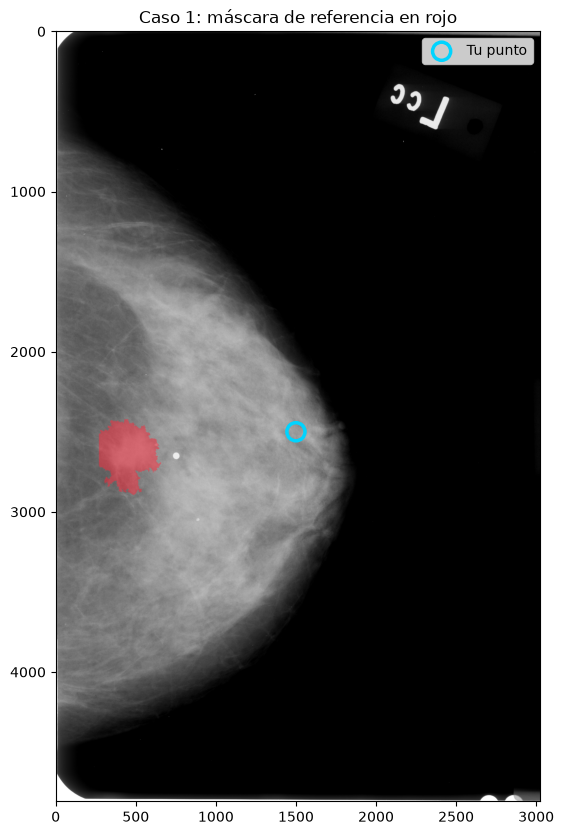

Patología registrada: MALIGNANT
Evaluación registrada: 4


In [17]:
def revelar(numero, x=None, y=None):
    c = casos[numero - 1]
    imagen = leer_imagen(c['imagen'])
    mascara = leer_mascara(c['mascara'])
    if imagen.shape != mascara.shape or not mascara.any():
        raise ValueError('Imagen y máscara no coinciden o la máscara está vacía.')
    fig, ax = plt.subplots(figsize=(7, 10))
    ax.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    rojo = np.zeros((*mascara.shape, 4), dtype=np.uint8)
    rojo[mascara] = [255, 38, 56, 128]
    ax.imshow(rojo)
    if x is not None and y is not None:
        ax.scatter([x], [y], s=170, facecolors='none', edgecolors='#00d4ff', linewidths=2.5, label='Tu punto')
        ax.legend(loc='upper right')
    ax.set_xlim(0, imagen.shape[1]); ax.set_ylim(imagen.shape[0], 0)
    ax.set_title(f'Caso {numero}: máscara de referencia en rojo')
    plt.show()
    print('Patología registrada:', c['patologia'])
    print('Evaluación registrada:', c['evaluacion'])

revelar(1, x, y)


**Para conversar:** ¿Tu punto quedó dentro o cerca de la región marcada? ¿Qué partes de la lesión cubre la máscara? Una diferencia no significa por sí sola que tu razonamiento sea inválido: revisa escala, contraste y lo que habías identificado visualmente.

La máscara es una anotación de referencia para el hallazgo, no un diagnóstico. La etiqueta de patología pertenece al registro del caso; este ejercicio no permite inferir rendimiento de un algoritmo.


## 4. Repetir con dos casos distintos

**Caso 2:** otra masa. **Caso 3:** calcificaciones. En cada uno, observa primero; luego revisa los metadatos; finalmente revela la máscara. Completa una fila por caso en la tabla de abajo.


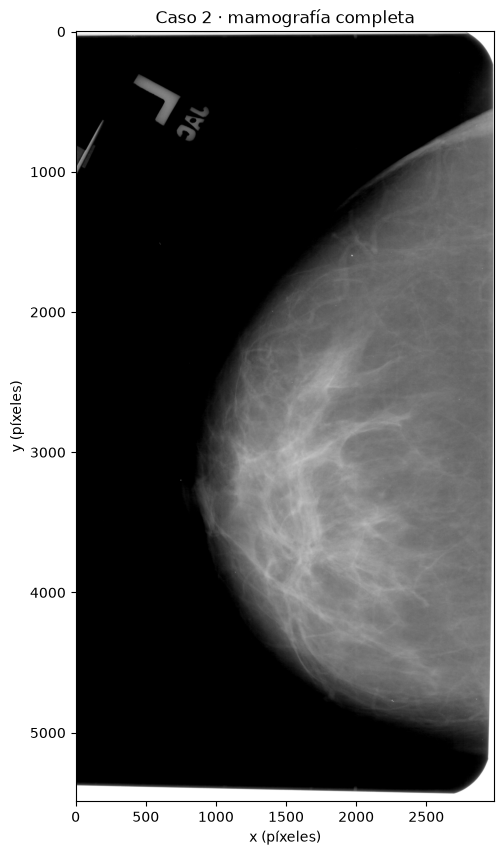

In [18]:
mostrar_imagen(2)


**Antes de continuar:** registra tu hipótesis para el caso 2. Luego consulta los metadatos.

In [19]:
metadatos(2)


Caso 2 | mama izquierda | vista CC
Tipo de hallazgo anotado: masa
Densidad registrada: 3
DICOM: 5491 × 2986 píxeles | 16 bits | MONOCHROME2
Forma: ARCHITECTURAL_DISTORTION | márgenes: ILL_DEFINED


**Ahora elige un punto.** Cambia las coordenadas del siguiente bloque antes de ejecutarlo.

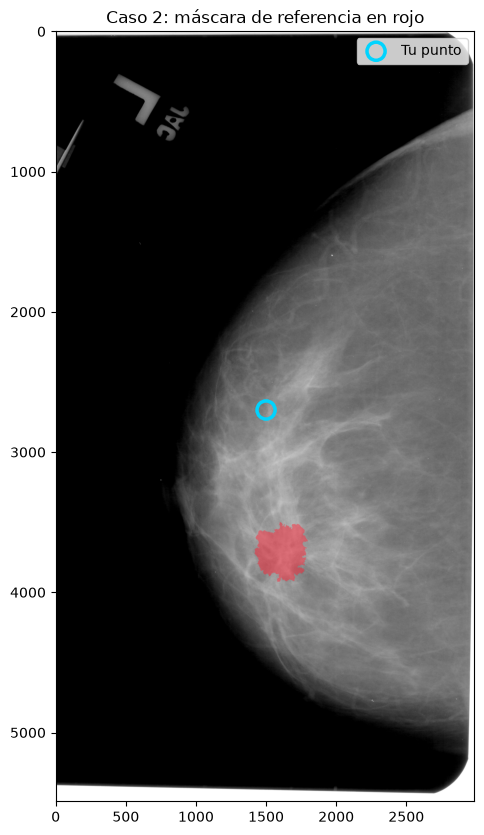

Patología registrada: BENIGN
Evaluación registrada: 4


In [20]:
x2, y2 = 1500, 2700  # Tu punto para el caso 2.
revelar(2, x2, y2)


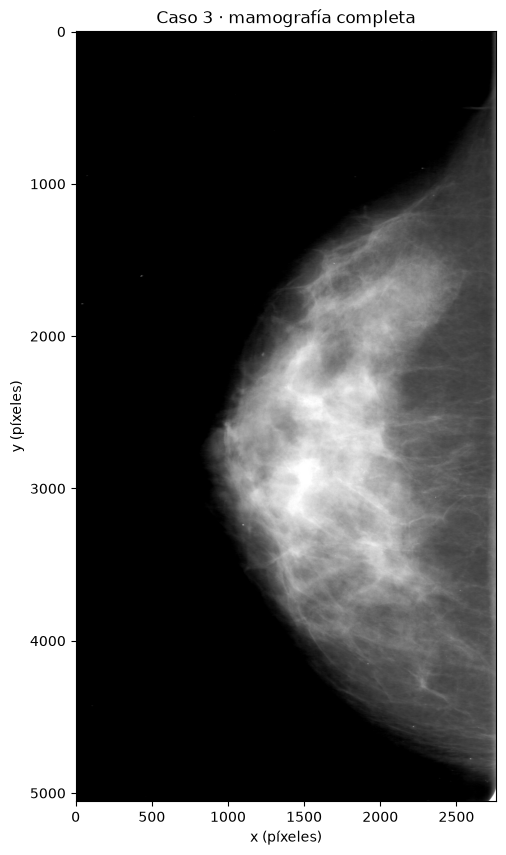

In [21]:
mostrar_imagen(3)


**Antes de continuar:** registra tu hipótesis para el caso 3. Luego consulta los metadatos.

In [23]:
metadatos(3)


Caso 3 | mama derecha | vista CC
Tipo de hallazgo anotado: calcificaciones
Densidad registrada: 3
DICOM: 5056 × 2761 píxeles | 16 bits | MONOCHROME2
Tipo de calcificación: AMORPHOUS | distribución: CLUSTERED


**Ahora elige un punto.** Cambia las coordenadas del siguiente bloque antes de ejecutarlo.

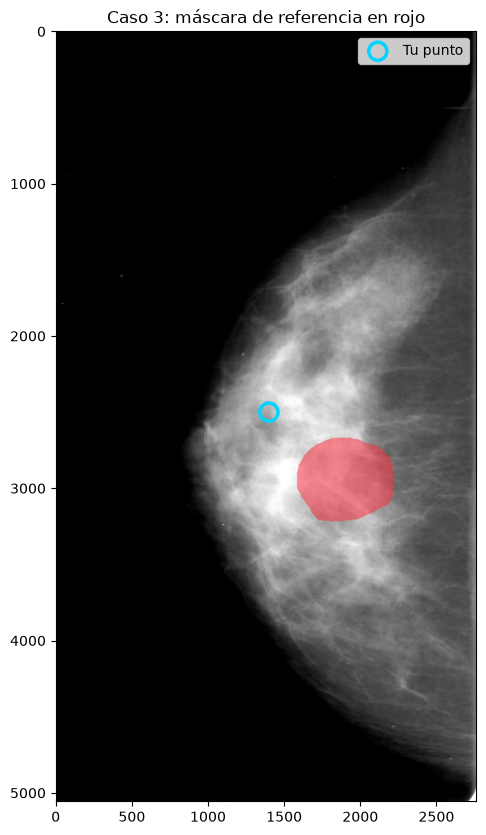

Patología registrada: MALIGNANT
Evaluación registrada: 3


In [24]:
x3, y3 = 1400, 2500  # Tu punto para el caso 3.
revelar(3, x3, y3)


| Caso | ¿Qué observaste primero? | ¿Dónde marcaste? | ¿Qué cambió al ver la máscara? |
|---|---|---|---|
| 1 · masa | | | |
| 2 · masa | | | |
| 3 · calcificaciones | | | |

## Cierre

1. ¿Qué diferencia hay entre **clasificar** un caso y **localizar** una anomalía?
2. ¿Por qué conviene registrar una hipótesis antes de mostrar la máscara?
3. ¿Qué información faltaría para evaluar un detector de IA de forma responsable?

**Idea clave:** la IA puede aprender patrones a partir de imágenes y anotaciones, pero este notebook solo muestra el flujo de observación y comparación. No entrena ni evalúa un modelo.

**Fuente:** [CBIS-DDSM, The Cancer Imaging Archive](https://www.cancerimagingarchive.net/collection/cbis-ddsm/). Copias verificadas de los DICOM de CBIS-DDSM; metadatos de los CSV de descripción de casos. Datos publicados bajo CC BY 3.0. La visualización ajusta el contraste para la pantalla; no altera los DICOM guardados. Este material no es adecuado para interpretación clínica.
